In [1]:
import os
import random
import math
import json
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset
import matplotlib.pyplot as plt
from collections import defaultdict
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, GPT2Config, TrainingArguments, Trainer, DataCollatorWithPadding, PreTrainedTokenizerFast
from tokenizers import SentencePieceBPETokenizer, pre_tokenizers

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device: {device}")

PyTorch device: cuda


# Stage 1

## Load Dataset

In [2]:
# This does not work: "RuntimeError: Dataset scripts are no longer supported, but found ptb_text_only.py"
#dataset = load_dataset("ptb_text_only")

data_files = {
    "train": "https://raw.githubusercontent.com/wojzaremba/lstm/master/data/ptb.train.txt",
    "test": "https://raw.githubusercontent.com/wojzaremba/lstm/master/data/ptb.test.txt",
    "valid": "https://raw.githubusercontent.com/wojzaremba/lstm/master/data/ptb.valid.txt",
}
dataset = load_dataset("text", data_files=data_files)
del data_files

## Preprocess and Tokenize

In [3]:
# Join all rows in all splits by newlines
joined_text = "\n".join([row["text"] for split in dataset.values() for row in split])
print(f"Total characters: {len(joined_text)}")

if not os.path.isfile("corpus.txt"):
    with open("corpus.txt", "w") as f:
        f.write(joined_text)

"""
# I spent four hours tyring to use the official sentencepiece library but nothing I tried could get it to work with hf's AutoTokenizer for stage 2
# But, the HF version does not provide the character_coverage argument

SentencePieceTrainer.train(
    input="corpus.txt",
    model_type="unigram",
    model_prefix="tokenizer",
    vocab_size=8000,
    character_coverage=1.0,
    pad_id=0,
    pad_piece="<pad>",
    unk_id=1,
    unk_piece="<unk>",
    bos_id=2,
    bos_piece="<bos>",
    eos_id=3,
    eos_piece="<eos>",
    minloglevel=10
)

tokenizer = SentencePieceProcessor()
tokenizer.load("tokenizer.model")
"""

tokenizer = SentencePieceBPETokenizer()
tokenizer.train(
    "corpus.txt",
    vocab_size=8000,
    show_progress=True,
    special_tokens = ["<unk>","<s>","</s>","<pad>"],
    initial_alphabet=pre_tokenizers.ByteLevel.alphabet()
)

joined_tokens = tokenizer.encode(joined_text)
print(f"Total tokens: {len(joined_tokens)}")

del joined_tokens, joined_text

tokenized_dataset = {
    split: tokenizer.encode("\n".join([row["text"] for row in dataset[split]])).ids
    for split in ["train", "test", "valid"]
}

Total characters: 5951344



Total tokens: 1222488


## Initialize Model

In [4]:
config = GPT2Config(
    vocab_size=tokenizer.get_vocab_size(),
    n_positions=128,
    n_ctx=128,
    n_embd=256,
    n_layer=4,
    n_head=4,
    n_inner=1024,
    embd_pdrop=0.1,
    attn_pdrop=0.1,
    resid_pdrop=0.1,
    tie_word_embeddings=True,
    bos_token_id=tokenizer.token_to_id("<s>"),
    eos_token_id=tokenizer.token_to_id("</s>"),
    pad_token_id=tokenizer.token_to_id("<pad>"),
    unk_token_id=tokenizer.token_to_id("<unk>")
)
model = AutoModelForCausalLM.from_config(config)
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(8000, 256)
    (wpe): Embedding(128, 256)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPT2Block(
        (ln_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=768, nx=256)
          (c_proj): Conv1D(nf=256, nx=256)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=1024, nx=256)
          (c_proj): Conv1D(nf=256, nx=1024)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=256, out_features=8000, bias=False)
)

## Train

In [5]:
block_size = 128

class RandomBlocksDataset(TorchDataset):
    def __init__(self, tokens):
        self.tokens = tokens
        self.block_size = block_size
    def __len__(self):
        return len(self.tokens) // self.block_size
    def __getitem__(self, i):
        start = random.randint(0, len(self.tokens) - self.block_size - 1)
        x = torch.tensor(self.tokens[start:start + self.block_size], dtype=torch.long)
        y = torch.tensor(self.tokens[start + 1:start + self.block_size + 1], dtype=torch.long)
        return {
            "input_ids": x,
            "labels": y,
            "attention_mask": torch.ones_like(x, dtype=torch.long)
        }


args = TrainingArguments(
    output_dir="pretraining",
    max_steps=3000,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,
    eval_strategy="steps",
    eval_steps=200,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=RandomBlocksDataset(tokenized_dataset["train"]),
    eval_dataset=RandomBlocksDataset(tokenized_dataset["test"])
)

trainer.save_model("init") # Save this for Stage 2 part f

print("Training...")
model.config.use_cache = False
train_results = trainer.train()
logs = trainer.state.log_history
trainer.save_model("pretrained")


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Training...


Step,Training Loss,Validation Loss
200,6.811800,6.564479
400,6.433800,6.312527
600,6.353200,6.252376
800,6.287600,6.186582
1000,6.260800,6.131485
1200,6.216800,6.094336
1400,6.175600,6.082096
1600,6.161600,6.068516
1800,6.131200,6.034784
2000,6.112600,6.035539


Training loss: 6.0721
Validation loss: 6.005311012268066
Validation perplexity: 405.5771085783894


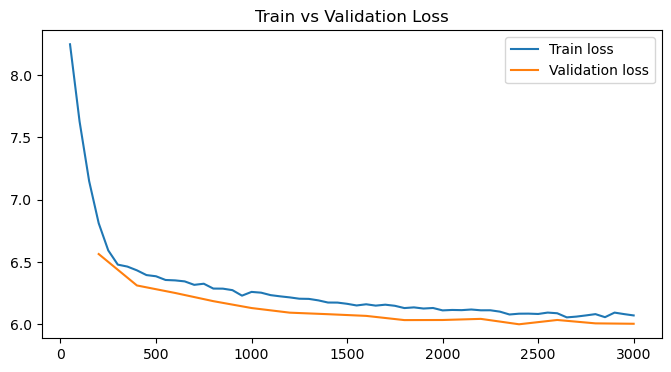

In [6]:
train_steps = [x["step"] for x in logs if "loss" in x and "learning_rate" in x]
train_loss  = [x["loss"] for x in logs if "loss" in x and "learning_rate" in x]
eval_steps  = [x["step"] for x in logs if "eval_loss" in x]
eval_loss   = [x["eval_loss"] for x in logs if "eval_loss" in x]

print(f"Training loss: {train_loss[-1]}")
print(f"Validation loss: {eval_loss[-1]}")
print(f"Validation perplexity: {math.exp(eval_loss[-1])}")


plt.figure(figsize=(8, 4))
plt.plot(train_steps, train_loss, label="Train loss")
plt.plot(eval_steps, eval_loss, label="Validation loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# Stage 2

## Load Dataset

In [7]:
tok = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer._tokenizer,
    pad_token="<pad>",
    eos_token="</s>",
    bos_token="<s>",
    unk_token="<unk>"
)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

ds = load_dataset("databricks/databricks-dolly-15k", split="train").shuffle(seed=42)

def format_dolly(ex):
    inst = (ex.get("instruction") or "").strip()
    resp = (ex.get("response") or "").strip()
    prompt = f"### Instruction:\n{inst}\n\n### Response:\n"
    text = prompt + resp
    return {"prompt": prompt, "text": text}

ds = ds.map(format_dolly, remove_columns=ds.column_names)
splits = ds.train_test_split(test_size=0.1, seed=42)
train_sft, val_sft = splits["train"], splits["test"]
len(train_sft), len(val_sft)

max_len = config.n_positions

def tokenize_sft(ex):
    prompt_ids = tok(ex["prompt"], truncation=True, max_length=max_len, padding=False)["input_ids"]
    full = tok(ex["text"], truncation=True, max_length=max_len, padding=False)

    input_ids = full["input_ids"]
    attn = full["attention_mask"]

    labels = input_ids.copy()
    prompt_len = min(len(prompt_ids), len(labels))
    for i in range(prompt_len):
        labels[i] = -100

    return {"input_ids": input_ids, "attention_mask": attn, "labels": labels, "prompt": ex["prompt"]}

train_tok = train_sft.map(tokenize_sft)
val_tok = val_sft.map(tokenize_sft)

padder = DataCollatorWithPadding(tokenizer=tok)

def collate(features):
    prompts = [f["prompt"] for f in features]
    feats = [{"input_ids": f["input_ids"], "attention_mask": f["attention_mask"]} for f in features]
    batch = padder(feats)

    maxT = batch["input_ids"].shape[1]
    labels = []
    for f in features:
        lab = f["labels"]
        if len(lab) < maxT:
            lab = lab + [-100]*(maxT - len(lab))
        else:
            lab = lab[:maxT]
        labels.append(lab)

    batch["labels"] = torch.tensor(labels, dtype=torch.long)
    batch["prompt"] = prompts
    return batch

Map:   0%|          | 0/15011 [00:00<?, ? examples/s]

Parameter 'function'=<function tokenize_sft at 0x7ffc74617d80> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.


Map:   0%|          | 0/13509 [00:00<?, ? examples/s]

Map:   0%|          | 0/1502 [00:00<?, ? examples/s]

## Train SFT Models

In [8]:
def sft_with_examples(num_examples):
    base_model = AutoModelForCausalLM.from_pretrained("./pretrained/", local_files_only=True)
        
    args = TrainingArguments(
        output_dir=f"sft_{num_examples}_checkpoints",
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=16,   # effective batch ~32
        num_train_epochs=10,
        learning_rate=5e-5,
        logging_steps=50,
        eval_strategy="steps",
        eval_steps=200,
        save_strategy="steps",
        save_steps=500,                  # ensures we save at least once
        fp16=torch.cuda.is_available(),
        remove_unused_columns=False,
        report_to="none"
    )
    
    trainer = Trainer(
        model=base_model,
        args=args,
        train_dataset=train_tok.select(range(num_examples)),
        eval_dataset=val_tok,
        data_collator=collate,
    )
    
    trainer.train()
    trainer.save_model(f"sft_{num_examples}")

sft_with_examples(200)
sft_with_examples(2000)

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


Step,Training Loss,Validation Loss


The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


Step,Training Loss,Validation Loss
200,6.182300,6.072483
400,5.778400,5.746720
600,5.649600,5.650022


## Generation

In [9]:
@torch.no_grad()
def generate_one(model, prompt, max_new_tokens=80, do_sample=True, temperature=0.8, top_p=0.9, num_beams=1):
    assert max_new_tokens <= model.config.n_positions
    model.eval()
    x = tok(prompt, return_tensors="pt").to(device)
    y = model.generate(
        **x,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        pad_token_id=tok.pad_token_id,
        eos_token_id=tok.eos_token_id,
    )
    return tok.decode(y[0], skip_special_tokens=True)


PROMPTS = [
    "Summarize in one sentence: Neural networks learn representations from data.",
    "Give 3 bullet points about overfitting.",
    "Translate to French: hello world",
    "Classify sentiment as positive or negative: I hated this movie.",
    "Rewrite in passive voice: The dog chased the cat.",
    "Extract JSON with keys name and age: John is 25 years old."
]
for m in ["init", "pretrained", "sft_200", "sft_2000"]:
    print(f"Model: {m}")
    model = AutoModelForCausalLM.from_pretrained(f"./{m}/", local_files_only=True)
    model.to(device)
    for p in PROMPTS:
        print(f"\t{p} (greedy) -> {generate_one(model, p, top_p=1.0)}")
        print(f"\t{p} (top-p) -> {generate_one(model, p, top_p=0.69)}")
    del model
    print("-" * 100)

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


Model: init
	Summarize in one sentence: Neural networks learn representations from data. (greedy) -> Summarize in one sentence: Neural networks learn representations from data. harryightened assist longer increasing cour governmentsĘ delayed disasters martin slowdown adequ sizable dedightenediumilies-se eu themgerger renhib sizable how bases machin machin ren crash crash crashivan disasters violationsrem return series now lux employedisedvernivan dam survished financier dayivity monitor apparent around employed victoryolutely heart fac facbster machin closing longerivan demands one-thtch¡ risenump reach police credibilityiuments
	Summarize in one sentence: Neural networks learn representations from data. (top-p) -> Summarize in one sentence: Neural networks learn representations from data. martin policeogr largely fal belief bases bases bronaumaumivanudman longer philiachusetts ties-se quebecor krenz krenz spir contr fac martin conservatives day important aroundiodees county although p

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


	Extract JSON with keys name and age: John is 25 years old. (greedy) -> Extract JSON with keys name and age: John is 25 years old. sizable legisldie improving contrict besides chentsollger police martin matters pull longerixita bases ruli now lineterishedosing dividend pullaumler them apparent surprising bases demands resolutionivan ru sizable largely assistushingushing rey them brewing newly martin series adequ ru hampshire demands voterem krenz producing ru aluminum around largely luxivantsburgh expectedbster fal sullivan carolina conservatives adequ vote martin coffee
	Extract JSON with keys name and age: John is 25 years old. (top-p) -> Extract JSON with keys name and age: John is 25 years old. apparent around adequivan machin sizableentsivan brewing ruivan fore policete police toronto governments adequaum risen spe important station contr buyer important seriesolutelyaum sen comprom contr conservatives martin brewing petites ru buyerium seriesivanaumivanivan martin pull euro pull 

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


	Extract JSON with keys name and age: John is 25 years old. (greedy) -> Extract JSON with keys name and age: John is 25 years old. but N the   it in with 
 N   
  in  
 
  in 
  a have      a 
   
 in 
  about   of
	Extract JSON with keys name and age: John is 25 years old. (top-p) -> Extract JSON with keys name and age: John is 25 years old.                                             
  
----------------------------------------------------------------------------------------------------
Model: sft_200
	Summarize in one sentence: Neural networks learn representations from data. (greedy) -> Summarize in one sentence: Neural networks learn representations from data.       
       at  m  a        the                was the     ing              N as   in   for   of    m  that
	Summarize in one sentence: Neural networks learn representations from data. (top-p) -> Summarize in one sentence: Neural networks learn representations from data.                                                     

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


	Extract JSON with keys name and age: John is 25 years old. (greedy) -> Extract JSON with keys name and age: John is 25 years old.      of and  and    that        on a   N    on    a   by the the  with              is a       his                  
	Extract JSON with keys name and age: John is 25 years old. (top-p) -> Extract JSON with keys name and age: John is 25 years old.                                                                                
----------------------------------------------------------------------------------------------------
Model: sft_2000
	Summarize in one sentence: Neural networks learn representations from data. (greedy) -> Summarize in one sentence: Neural networks learn representations from data. dh   manrngu iceda  ic o, -  is is  is      is          was  e sa     der  e       ding   .      
	Summarize in one sentence: Neural networks learn representations from data. (top-p) -> Summarize in one sentence: Neural networks learn representations from data

# Stage 3

## Eval 1

In [10]:
def neighbors(embeddings, word, n=8):
    id_word = tok(word)["input_ids"]
    assert len(id_word) == 1
    id_word = id_word[0]
    
    e_word = embeddings[id_word]
    sims = F.cosine_similarity(e_word.unsqueeze(0), embeddings, dim=1)
    vals, idxs = torch.topk(sims, k=min(n + 1, embeddings.shape[0]))
    return [
        (tok.decode([i]), v)
        for v, i in zip(vals.tolist(), idxs.tolist())
        if i != id_word
    ]

for m in ["pretrained", "sft_200", "sft_2000"]:
    print(f"Model: {m}")
    model = AutoModelForCausalLM.from_pretrained(f"./{m}/", local_files_only=True)
    model.to(device)
    E = model.get_input_embeddings().weight
    for w in ["bank", "money", "good", "bad"]:
        print(f"\t{w}:")
        for w2, score in neighbors(E, w):
            print(f"\t\t{w2} -> {score:.5f}")
    
    del model
    print("-" * 100)

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.
The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.
The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


Model: pretrained
	bank:
		and -> 0.33733
		of -> 0.31434
		's -> 0.30098
		company -> 0.28986
		market -> 0.28868
		said -> 0.28689
		from -> 0.27900
		business -> 0.27846
	money:
		u.s. -> 0.25785
		program -> 0.23065
		
 -> 0.22827
		 -> 0.22569
		this -> 0.21946
		on -> 0.21896
		all -> 0.21035
		come -> 0.20439
	good:
		make -> 0.23555
		clear -> 0.20251
		he -> 0.20131
		too -> 0.19354
		worked -> 0.19267
		n't -> 0.19235
		been -> 0.19034
		much -> 0.18190
	bad:
		bud -> 0.30533
		symb -> 0.26597
		appoint -> 0.25886
		nabisco -> 0.25838
		rodu -> 0.25250
		right -> 0.24413
		legislators -> 0.23792
		spirit -> 0.23470
----------------------------------------------------------------------------------------------------
Model: sft_200
	bank:
		and -> 0.31509
		of -> 0.29453
		company -> 0.28119
		's -> 0.28055
		market -> 0.27914
		said -> 0.27007
		business -> 0.26872
		price -> 0.26736
	money:
		u.s. -> 0.25551
		
 -> 0.23168
		program -> 0.22915
		this -> 0.22510
		on -> 0.22030

## Eval 2

In [13]:
for m in ["pretrained", "sft_200", "sft_2000"]:
    print(f"Model: {m}")
    model = AutoModelForCausalLM.from_pretrained(f"./{m}/", local_files_only=True)
    model.to(device)

    BANK = tok("bank")["input_ids"][0]
    
    S1 = "I went to the bank to deposit money."
    S2 = "The river overflowed the bank after the storm."

    e_s1 = tok(S1)["input_ids"]
    e_s2 = tok(S1)["input_ids"]

    enc1 = {k: v.to(device) for k, v in tok(S1, return_tensors="pt").items()}
    enc2 = {k: v.to(device) for k, v in tok(S2, return_tensors="pt").items()}

    out1 = model(**enc1, output_hidden_states=True, return_dict=True)
    out2 = model(**enc2, output_hidden_states=True, return_dict=True)

    x_s1 = out1.hidden_states[-1].squeeze(0)   # [seq, hidden]
    x_s2 = out2.hidden_states[-1].squeeze(0)   # [seq, hidden]

    bank1 = x_s1[e_s1.index(BANK)].tolist()
    bank2 = x_s2[e_s2.index(BANK)].tolist()

    print("'bank' similarity: ", end="")
    print(np.dot(bank1, bank2) / (np.linalg.norm(bank1) * np.linalg.norm(bank2)))
    
    del model
    print("-" * 100)

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.
The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.
The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


Model: pretrained
'bank' similarity: 0.9042052205061177
----------------------------------------------------------------------------------------------------
Model: sft_200
'bank' similarity: 0.9081529705430981
----------------------------------------------------------------------------------------------------
Model: sft_2000
'bank' similarity: 0.9546286915775439
----------------------------------------------------------------------------------------------------


## Eval 3

In [14]:
for m in ["pretrained", "sft_200", "sft_2000"]:
    print(f"Model: {m}")
    model = AutoModelForCausalLM.from_pretrained(f"./{m}/", local_files_only=True)
    model.to(device)

    texts = [row["text"] for row in dataset["valid"]]

    texts = texts[:min(500, len(texts))]
    
    enc = tok(texts, return_tensors="pt", padding=True, truncation=True)
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    
    labels = input_ids.clone()
    labels[attention_mask == 0] = -100
    
    out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    ppl = math.exp(out.loss.item())
    
    print(f"Perplexity: {ppl:.3f}")

    del model, enc, input_ids, attention_mask, labels, out, ppl
    torch.cuda.empty_cache()
    
    print("-" * 100)

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Model: pretrained


The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


Perplexity: 741.967
----------------------------------------------------------------------------------------------------
Model: sft_200


The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


Perplexity: 947.433
----------------------------------------------------------------------------------------------------
Model: sft_2000
Perplexity: 845.276
----------------------------------------------------------------------------------------------------


# Stage 4

1. Using Eval 3, did SFT increase PTB perplexity? Why would this happen? *Yes (741 to 947/845), because the fine tuning may result in behaviors that increase loss even if the results look better to humans*
2. Using Eval 1 or Eval 2, describe one measurable change in representation between pretraining and SFT. *In eval 2, the 2000 example SFT model had an increase in similarity between bank and business related words like company (0.29 vs 0.28)*
3. Compare greedy vs top-p outputs. Which better reflects instruction-following behavior and why? *Regardless of which one was used, the outputs were still incomprehensible*
4. Describe your ablation (freeze or data-size). What changed quantitatively? *In eval 3, more SFT examples decreased perplexity (947 to 845)*